<a href="https://colab.research.google.com/github/divyasri2609/Medical-Transcriptions/blob/main/MEDICAL%20SPECIALTY%20CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

import zipfile
import os

zip_path = "/content/archive (10).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files extracted:", os.listdir("data"))

Saving archive (10).zip to archive (10).zip
Files extracted: ['mtsamples.csv']


In [15]:
!pip install nltk

In [58]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_advanced(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z ]', '', text)

        words = text.split()
        words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

        return " ".join(words)
    else:
        return ""

df['clean_text'] = df['transcription'].apply(clean_text_advanced)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [57]:
top_classes = df['medical_specialty'].value_counts().head(10).index

df = df[df['medical_specialty'].isin(top_classes)]

print(df['medical_specialty'].value_counts())

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64


In [19]:
X = df['clean_text']
y = df['medical_specialty']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # BIG IMPROVEMENT
    min_df=2,
    max_df=0.9,
    stop_words='english'
)

In [21]:
model = LogisticRegression(max_iter=300, class_weight='balanced')

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=300)

In [23]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_tfidf, y_train)

LinearSVC()

In [37]:
y_pred = model.predict(X_test_tfidf)

In [59]:
from sklearn.model_selection import GridSearchCV

params = {
    'loss': ['hinge', 'log_loss'],
    'alpha': [0.0001, 0.001, 0.01],
    'penalty': ['l2', 'l1', 'elasticnet']
}

grid = GridSearchCV(SGDClassifier(random_state=42), params, cv=3, n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

model = grid.best_estimator_
print(f"Best parameters: {grid.best_params_}")

Best parameters: {'alpha': 0.001, 'loss': 'log_loss', 'penalty': 'elasticnet'}


In [38]:
print(classification_report(y_test, y_pred))

                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.50      0.23      0.31        74
    Consult - History and Phy.       0.41      0.90      0.57       103
              Gastroenterology       0.00      0.00      0.00        46
              General Medicine       0.00      0.00      0.00        52
                     Neurology       0.26      0.13      0.18        45
       Obstetrics / Gynecology       0.50      0.03      0.06        32
                    Orthopedic       0.18      0.04      0.07        71
                     Radiology       0.40      0.11      0.17        55
 SOAP / Chart / Progress Notes       0.00      0.00      0.00        33
                       Surgery       0.51      0.96      0.67       221

                      accuracy                           0.46       732
                     macro avg       0.28      0.24      0.20       732
                  weighted avg       0.35      0.46      0.35 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


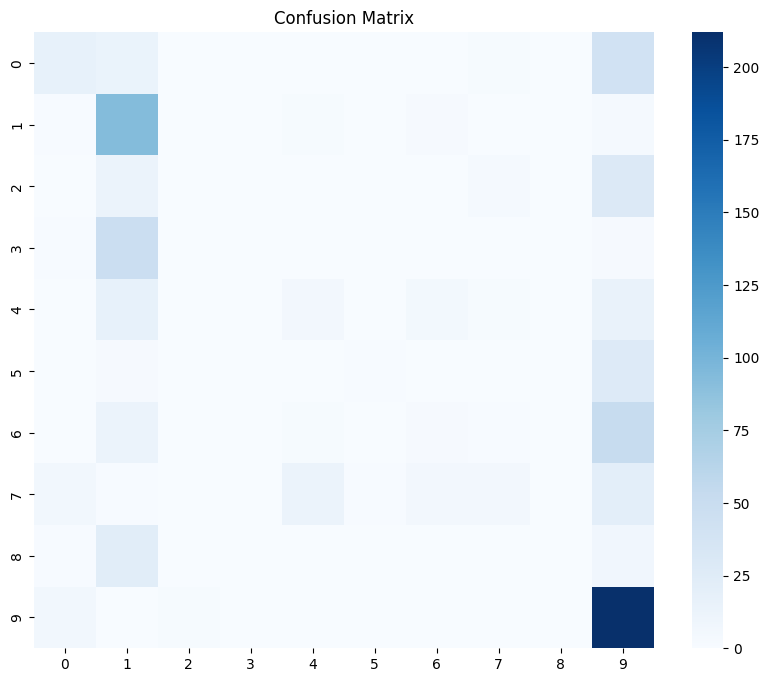

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [13]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

confused = results[results['Actual'] != results['Predicted']]

confused.head(10)

,Actual,Predicted
1343,SOAP / Chart / Progress Notes,Orthopedic
2807,Neurology,Consult - History and Phy.
743,Surgery,Cardiovascular / Pulmonary
1643,Radiology,Neurology
3230,General Medicine,SOAP / Chart / Progress Notes
2331,Orthopedic,Surgery
2156,Orthopedic,Neurology
2106,Orthopedic,Surgery
2808,Neurology,Consult - History and Phy.
1563,Radiology,Orthopedic


In [60]:
import lightgbm as lgb

lgbm_w2v_model = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
lgbm_w2v_model.fit(X_train_w2v, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 2925, number of used features: 300
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


LGBMClassifier(class_weight='balanced', random_state=42)

In [54]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the LGBMClassifier with class_weight='balanced' for imbalanced datasets
lgbm_w2v_model = lgb.LGBMClassifier(random_state=42, class_weight='balanced')

# Train the model using Word2Vec features
lgbm_w2v_model.fit(X_train_w2v, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 2925, number of used features: 300
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


LGBMClassifier(class_weight='balanced', random_state=42)

In [62]:
y_pred_lgbm_w2v = lgbm_w2v_model.predict(X_test_w2v)
print(classification_report(y_test, y_pred_lgbm_w2v))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.13      0.11      0.12        74
    Consult - History and Phy.       0.30      0.36      0.33       103
              Gastroenterology       0.04      0.04      0.04        46
              General Medicine       0.09      0.10      0.09        52
                     Neurology       0.08      0.09      0.09        45
       Obstetrics / Gynecology       0.07      0.06      0.07        32
                    Orthopedic       0.13      0.11      0.12        71
                     Radiology       0.17      0.16      0.17        55
 SOAP / Chart / Progress Notes       0.17      0.12      0.14        33
                       Surgery       0.40      0.42      0.41       221

                      accuracy                           0.23       732
                     macro avg       0.16      0.16      0.16       732
                  weighted avg       0.23      0.23      0.23 

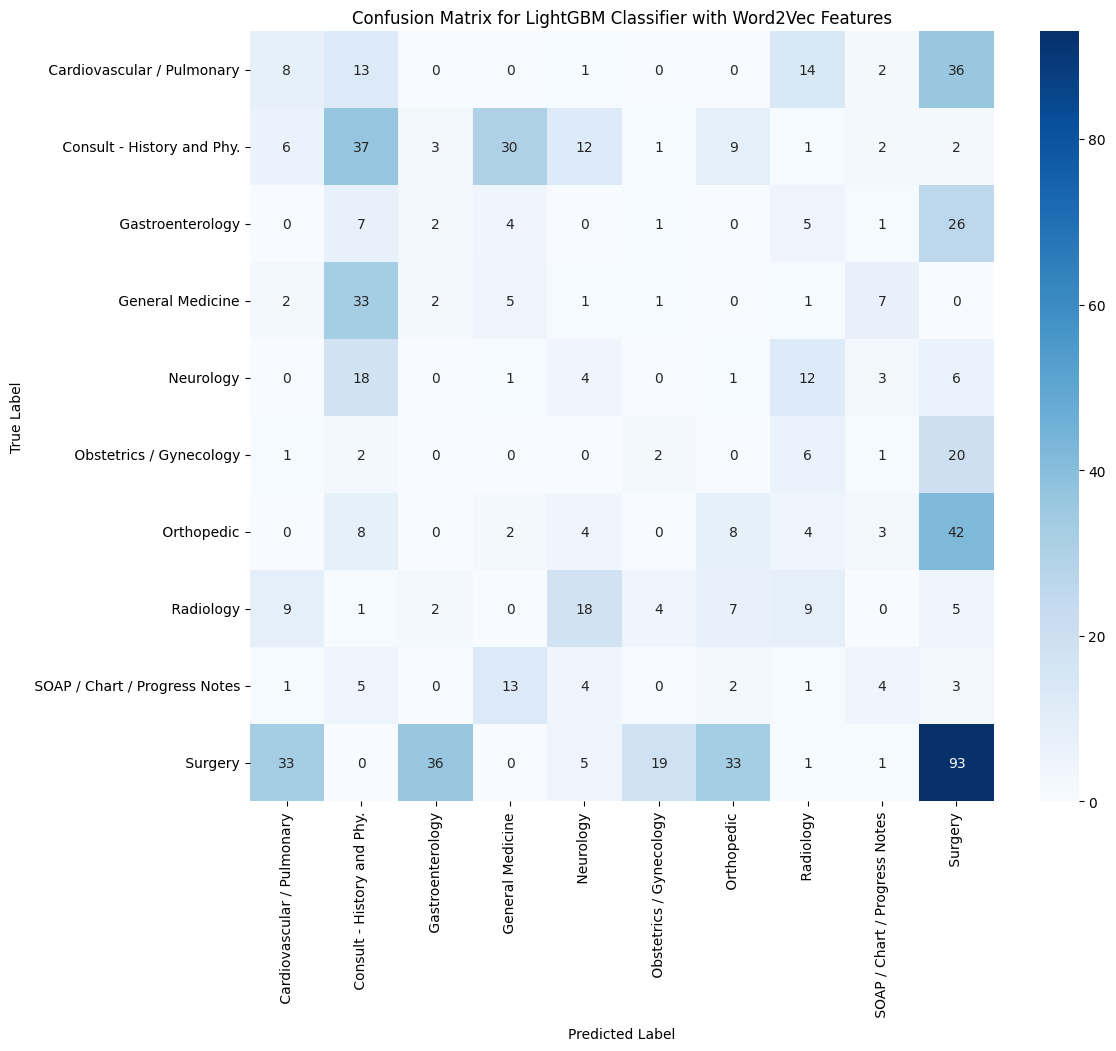

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_lgbm_w2v = confusion_matrix(y_test, y_pred_lgbm_w2v)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_lgbm_w2v, annot=True, fmt='d', cmap='Blues', xticklabels=lgbm_w2v_model.classes_, yticklabels=lgbm_w2v_model.classes_)
plt.title("Confusion Matrix for LightGBM Classifier with Word2Vec Features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()